In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [7]:
data = np.load("20260414_100939.npz")
#print(data.files)   # List all arrays stored in the file
data=data['matrix'][:,:484]

In [13]:
for i in range(5):
    img = data[i].reshape(22, 22)

    plt.imshow(img)
    plt.axis("off")
    plt.savefig(f"image_{i:04d}.png", bbox_inches="tight", pad_inches=0)
    plt.close()

In [25]:
def data_generation(num_elements,real_data):

    
    # Choose random data samples to calculate the distance from
    elements1 = np.random.choice(len(real_data), num_elements, replace=True)
    # Choose random data samples to calculate the distance to
    delta = np.random.choice(len(real_data) - 1, num_elements, replace=True) + 1
    elements2 = elements1 + delta
    # Push the second elements to the range if they are outside
    elements2[elements2 >= len(real_data)] = elements2[elements2 >= len(real_data)] - len(real_data)
    distances_L2 = np.linalg.norm(real_data[elements1] - real_data[elements2], axis = 1)
    #print((real_data[elements1]).shape)
    
    # Sort all the distances from the smallest to the largest.
    distances_L2_sorted = np.sort(distances_L2)
    n = len(distances_L2_sorted)

    return distances_L2_sorted,n

def confidence_interval(n,distances_L2_sorted,num_elements,N_val):
    
    # 95 percent confidence intercal
    epsilon = np.sqrt(np.log(2 / 0.05) / (2 * n))  # Using confidence of 95% (alpha = 0.05)
    cdf_lower = np.maximum(0, np.arange(1, n + 1) / n - epsilon)
    cdf_upper = np.minimum(1, np.arange(1, n + 1) / n + epsilon)
    
    # C(r) vs r plot
    x_axis = np.log(distances_L2_sorted)
    y_axis = np.log(range(len(distances_L2_sorted)))
    q = (np.arange(0, len(distances_L2_sorted)) + 0.5)/num_elements
    
    # Slicing the log-log plot to get slopes at different areas
    x_axis = np.log(distances_L2_sorted)
    #N_val = 50
    k = len(y_axis)//N_val
    y_change = y_axis[k::k] - y_axis[0:-k:k]
    x_change = x_axis[k::k] - x_axis[0:-k:k]
    slopes = y_change/x_change
    slopes_number = slopes[~np.isnan(slopes)]
    
    
    # Calculating the confidence intervals
    z_alpha = 2
    up = q + z_alpha * np.sqrt(q*(1-q) / num_elements)
    up[up > 1] = 1
    low = q - z_alpha * np.sqrt(q*(1-q) / num_elements)
    low[low < 0] = 0
    log_up = np.log(up)
    log_low = np.log(low)

    return log_up,log_low,x_axis,q

def estimate_slope(distances_L2_sorted,N_val,log_up,log_low,q):
    

        
    # Calculating the confidence intervals for the interval slices
    dist_ratio = np.exp(np.log(distances_L2_sorted[-1]/distances_L2_sorted[0])/N_val)
    ind1 = 0
    idup = []
    idlow = []
    idest = []
    d = []
    d1=[]
    indices = []
    mean_th=[]
    for i in range(N_val):
        ind2 = np.argmax(distances_L2_sorted > distances_L2_sorted[ind1] * dist_ratio)
        if ind2 == 0 or ind2>=len(distances_L2_sorted):
            break
        else:
            idup.append((log_up[ind2] - log_low[ind1])/(np.log(distances_L2_sorted[ind2]) - np.log(distances_L2_sorted[ind1])) )
            idlow.append((log_low[ind2] - log_up[ind1])/(np.log(distances_L2_sorted[ind2]) - np.log(distances_L2_sorted[ind1])) )
            idest.append((np.log(q[ind2]) - np.log(q[ind1]))/ (np.log(distances_L2_sorted[ind2]) - np.log(distances_L2_sorted[ind1]))) # Estimated slope
            print((np.log(q[ind2]) - np.log(q[ind1])))
            d.append(np.sqrt(distances_L2_sorted[ind2] * distances_L2_sorted[ind1])) # Geometric mean
            indices.append(ind1)
            ind1 = ind2
        #mean_th.append(np.mean(slope_th[(i)*(len(slope_th)//N_val):(i+1)*(len(slope_th)//N_val)]))
    idup = np.array(idup)
    idlow = np.array(idlow)
    idest = np.array(idest)
    #mean_th = np.array(mean_th)
    idlow[idlow < 0] = 0
    indices = np.array(indices)

    return idup,idlow,idest,d


In [32]:
num_elements = len(data)*20
distances_L2_sorted,n=data_generation(num_elements,data)
log_up,log_low,x_axis,q=confidence_interval(n,distances_L2_sorted,num_elements,N_val=50)

/var/folders/cn/kwjgrgns35l8b9qxq0p_15qm0000gn/T/ipykernel_89508/3099629104.py:29: RuntimeWarning: divide by zero encountered in log
  y_axis = np.log(range(len(distances_L2_sorted)))
/var/folders/cn/kwjgrgns35l8b9qxq0p_15qm0000gn/T/ipykernel_89508/3099629104.py:49: RuntimeWarning: divide by zero encountered in log
  log_low = np.log(low)


In [33]:
idup, idlow, idest, d=estimate_slope(distances_L2_sorted,50,log_up,log_low,q)

1.9459101490553135
0.8873031950009036
0.6007738604289301
0.37267528528517246
0.27087495413540097
0.12715517548524602
0.16475523307605489
0.32190002976212284
0.8577282026660757
0.9507109557606341
1.099614292759961
0.9506461948713696
0.7708498342536418
0.6242598251666944
0.4888703767036975
0.37701265405577944
0.2867485186983352
0.21303278350993515
0.1622502308392536
0.12238255889529859
0.08902663120152254
0.07039412712210841
0.05436262155943716
0.04488454736670672
0.03838284496578004
0.034640387587990984
0.029471732337220946
0.025017304048323058
0.025261327069152628
0.02395995679808799
0.02538765750031255
0.031467869728632636
0.036690211690519905
0.035182052411602306
0.02175057509029411
0.010675060590561405
0.005935485639935076
0.0034520273405628946
0.0022579942556408585
0.0011721451595995745
0.0007006270898800449
0.0003301254506683338
0.00010001650280631285
5.000450041545043e-05
4.000180008626668e-05
2.0000300005186765e-05


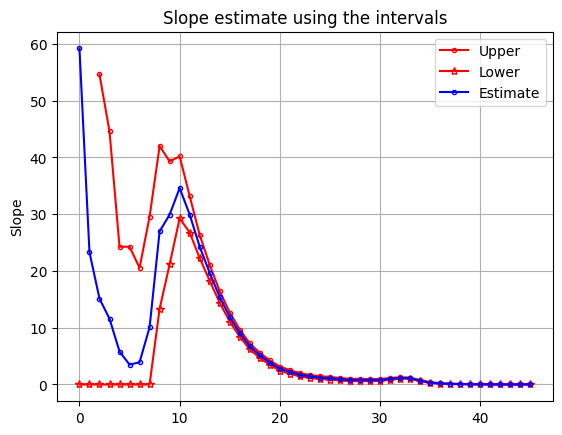

In [34]:
plt.figure
plt.plot(idup, color = "r", marker='.', fillstyle='none')
plt.plot(idlow, color = "r", marker='*', fillstyle='none')
plt.plot(idest, color = "b", marker='.', fillstyle='none')
plt.ylabel("Slope")
plt.title("Slope estimate using the intervals")
plt.legend(['Upper','Lower','Estimate','Theoretical bound'])
plt.grid(True)
plt.show()

In [ ]:
# =========================================================
# 1. Configuration
# =========================================================
# Path to the input .npz file
#FILE_PATH = "your_data.npz"

# Dimension of the latent representation
LATENT_DIM = 5

# Training hyperparameters
BATCH_SIZE = 128
EPOCHS = 500
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# =========================================================
# 2. Select computation device
# =========================================================
# Use CUDA if available, otherwise MPS (Apple Silicon),
# otherwise fall back to CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# =========================================================
# 3. Load data from .npz
# =========================================================
# Load the compressed NumPy archive
#npz_data = np.load(FILE_PATH)
data = np.load("20260414_100939.npz")
data=data['matrix'][:,:484]

#print("Stored arrays:", npz_data.files)

# Use the first array in the archive
#data_key = npz_data.files[0]
X = data

#print("Selected key:", data_key)
print("Original shape:", X.shape)

# Transpose if the data are stored as (484, N)
if X.shape == (484, 5000):
    X = X.T

# Verify that each sample has 484 features
assert X.shape[1] == 484

X = X.astype(np.float32)


# =========================================================
# 4. Normalize features
# =========================================================
# Standardize each feature independently
mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)

# Avoid division by zero
std[std < 1e-8] = 1.0

X = (X - mean) / std

X_tensor = torch.tensor(X, dtype=torch.float32)


# =========================================================
# 5. Split into training and validation sets
# =========================================================
dataset = TensorDataset(X_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# =========================================================
# 6. Define the Autoencoder
# =========================================================
class Autoencoder(nn.Module):
    def __init__(self, input_dim=484, latent_dim=16):
        super().__init__()

        # Encoder: maps input features to a low-dimensional latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        # Decoder: reconstructs the original input from the latent vector
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        # Encode the input into the latent space
        z = self.encoder(x)

        # Reconstruct the input from the latent representation
        x_hat = self.decoder(z)

        return x_hat


# =========================================================
# 7. Training setup
# =========================================================
model = Autoencoder(
    input_dim=484,
    latent_dim=LATENT_DIM
).to(device)

# Mean squared reconstruction error
criterion = nn.MSELoss()

# Adam optimizer with weight decay
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)


# =========================================================
# 8. Training loop
# =========================================================

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for (batch,) in train_loader:

        batch = batch.to(device)

        # Forward pass
        reconstructed = model(batch)

        # Compute reconstruction loss
        loss = criterion(reconstructed, batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)


# =========================================================
# 9. Extract latent embeddings
# =========================================================
model.eval()

with torch.no_grad():
    latent_vectors = model.encoder(X_tensor.to(device))
    reconstruction = model(X_tensor.to(device))
    mse = criterion(reconstruction,X_tensor.to(device)).item()

latent_vectors = latent_vectors.cpu().numpy()
print(f"Final reconstruction MSE = {mse:.6f}")

Using device: mps
Original shape: (5000, 484)


In [40]:
with torch.no_grad():
    latent_vectors = model.encoder(X_tensor.to(device))
    reconstruction = model(X_tensor.to(device))
    mse = criterion(reconstruction,X_tensor.to(device)).item()

latent_vectors = latent_vectors.cpu().numpy()
print(f"Final reconstruction MSE = {mse:.6f}")

Final reconstruction MSE = 0.639968


In [ ]:
# 5 : 0.699
# 10: 0.66872
# 20 : 0.645
# 30 : 0.639
# 50 : 0.649
# 100 : 0.641